# Financial Return Analysis

A small, transparent analysis of **ES** and **GC** daily returns. This is not a trading strategy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats


## 1. Download and validate data

Yahoo Finance is used as a convenient educational source, not as research-grade futures data.

In [2]:
TICKERS = {'ES': 'ES=F', 'GC': 'GC=F'}
START = '2021-01-01'
END = '2026-09-01'

raw = yf.download(list(TICKERS.values()), start=START, end=END, auto_adjust=False, progress=False)
prices = raw['Adj Close'].copy()
prices = prices.rename(columns={v: k for k, v in TICKERS.items()})
prices = prices[['ES', 'GC']].dropna(how='all')

print('Rows:', len(prices))
print('Date range:', prices.index.min().date(), 'to', prices.index.max().date())
display(prices.isna().sum())
display(prices.head())


Rows: 1424
Date range: 2021-01-04 to 2026-08-31


Ticker
ES    0
GC    1
dtype: int64

Ticker,ES,GC
Date,,
2021-01-04,3692.25,1944.699951
2021-01-05,3718.25,1952.699951
2021-01-06,3740.50,1906.900024
2021-01-07,3795.50,1912.300049
2021-01-08,3817.50,1834.099976


## 2. Daily simple returns

$r_t = P_t/P_{t-1} - 1$

In [3]:
returns = prices.pct_change(fill_method=None).dropna()
display(returns.head())


Ticker,ES,GC
Date,,
2021-01-05,0.007042,0.004114
2021-01-06,0.005984,-0.023455
2021-01-07,0.014704,0.002832
2021-01-08,0.005796,-0.040893
2021-01-11,-0.006680,0.008451


## 3. Descriptive statistics

In [4]:
summary = pd.DataFrame({
    'mean_daily_return': returns.mean(),
    'daily_volatility': returns.std(ddof=1),
    'annualized_volatility': returns.std(ddof=1) * np.sqrt(252),
    'skewness': returns.skew(),
    'excess_kurtosis': returns.kurt(),
    'minimum': returns.min(),
    'maximum': returns.max(),
})
display(summary)


,mean_daily_return,daily_volatility,annualized_volatility,skewness,excess_kurtosis,minimum,maximum
Ticker,,,,,,,
ES,0.000572,0.010487,0.166472,0.142932,6.620686,-0.059362,0.093770
GC,0.000644,0.011623,0.184515,-0.926308,8.626737,-0.113662,0.060833


## 4. Return distributions

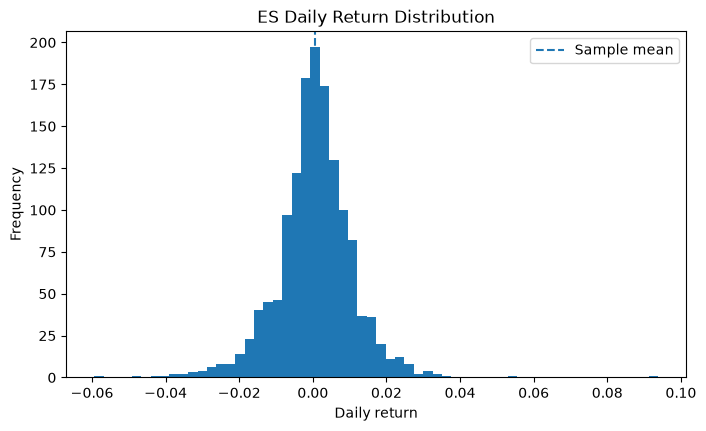

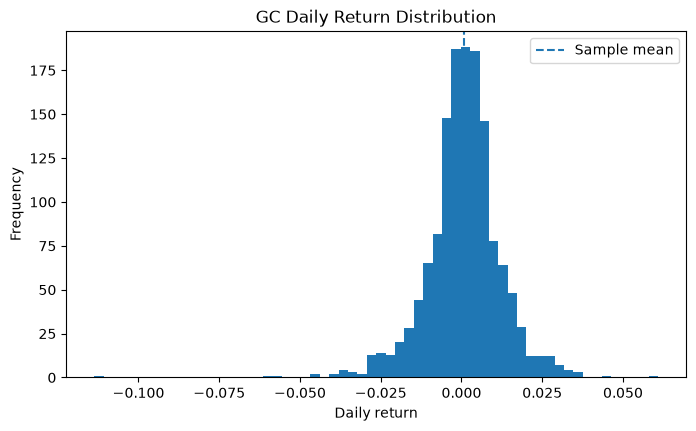

In [5]:
for market in returns.columns:
    plt.figure(figsize=(8, 4.5))
    plt.hist(returns[market].dropna(), bins=60)
    plt.axvline(returns[market].mean(), linestyle='--', label='Sample mean')
    plt.title(f'{market} Daily Return Distribution')
    plt.xlabel('Daily return')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


## 5. Rolling annualized volatility

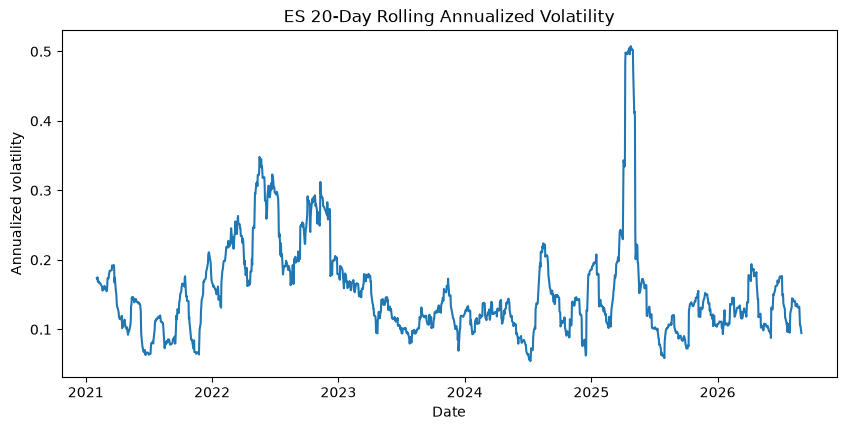

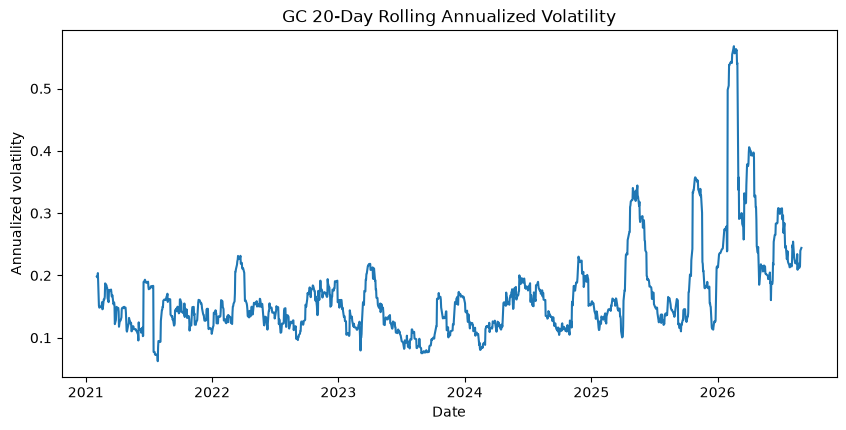

In [6]:
rolling_vol = returns.rolling(20).std(ddof=1) * np.sqrt(252)

for market in rolling_vol.columns:
    plt.figure(figsize=(10, 4.5))
    plt.plot(rolling_vol.index, rolling_vol[market])
    plt.title(f'{market} 20-Day Rolling Annualized Volatility')
    plt.xlabel('Date')
    plt.ylabel('Annualized volatility')
    plt.show()


## 6. Correlation

In [7]:
correlation = returns.corr()
display(correlation)
print(f"ES/GC daily-return correlation: {correlation.loc['ES', 'GC']:.4f}")


Ticker,ES,GC
Ticker,,
ES,1.000000,0.103924
GC,0.103924,1.000000


ES/GC daily-return correlation: 0.1039


## 7. Confidence intervals and one-sample t-tests

For each market, test $H_0: \\mu = 0$ against $H_1: \\mu \\neq 0$. This is an introductory inference exercise, not evidence of a trading edge.

In [8]:
results = []

for market in returns.columns:
    x = returns[market].dropna()
    n = len(x)
    mean = x.mean()
    sem = stats.sem(x)
    ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean, scale=sem)
    t_stat, p_value = stats.ttest_1samp(x, popmean=0.0)
    results.append({
        'market': market,
        'n': n,
        'mean_daily_return': mean,
        'ci_95_low': ci_low,
        'ci_95_high': ci_high,
        't_statistic': t_stat,
        'p_value': p_value,
    })

inference = pd.DataFrame(results).set_index('market')
display(inference)


,n,mean_daily_return,ci_95_low,ci_95_high,t_statistic,p_value
market,,,,,,
ES,1421,0.000572,0.000026,0.001118,2.056156,0.03995
GC,1421,0.000644,0.000039,0.001249,2.088280,0.03695


## 8. Interpretation checklist

Before drawing conclusions:

- Is the effect economically meaningful?
- Is it stable across sub-periods?
- Could vendor construction or futures-roll behavior matter?
- Was the hypothesis specified before exploring many alternatives?
- Would it survive true out-of-sample testing?
- Have costs and implementation constraints been considered?

The correct conclusion here is deliberately modest: this notebook describes the sample and demonstrates basic statistical inference. It does **not** validate a trading strategy.